<a href="https://colab.research.google.com/github/s-bishal/ML-Lab/blob/main/ML_Lab_Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##KNN

In [ ]:

import os
import glob
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import kagglehub

# 1. Download dataset using kagglehub
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
print("Path to dataset files:", path)

# Locate the CSV file dynamically
csv_files = glob.glob(os.path.join(path, "*.csv"))
if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded dataset directory.")

dataset_path = csv_files[0]
df = pd.read_csv(dataset_path)

print("\n--- 1. First 5 Records of Dataset ---")
print(df.head())

In [5]:
import os
import glob
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import kagglehub

# Check if df is already defined, if not, load it
# This ensures the cell can run even if previous data loading steps were skipped or kernel state was lost
if 'df' not in locals() and 'df' not in globals():
    print("DataFrame 'df' not found in current session. Reloading dataset...")
    path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
    csv_files = glob.glob(os.path.join(path, "*.csv"))
    if not csv_files:
        raise FileNotFoundError("No CSV file found in the downloaded dataset directory.")
    dataset_path = csv_files[0]
    df = pd.read_csv(dataset_path)
    print("Dataset reloaded.")

print("\n--- 2. Data Info Before Preprocessing ---")
display(df.info())

# Drop 'CustomerID' if it exists, as it's an identifier and not a feature
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Apply one-hot encoding to categorical features (e.g., 'Genre' or 'Gender')
if 'Genre' in df.columns:
    df = pd.get_dummies(df, columns=['Genre'], drop_first=True)
elif 'Gender' in df.columns:
    df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

# Assuming a target variable for classification demo purposes.
df['High_Spending'] = (df['Spending Score (1-100)'] > 50).astype(int)

X = df.drop(['High_Spending', 'Spending Score (1-100)'], axis=1) # Features
y = df['High_Spending'] # Target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- Data Splitting and Scaling Complete ---")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test.shape}")

DataFrame 'df' not found in current session. Reloading dataset...
Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Dataset reloaded.

--- 2. Data Info Before Preprocessing ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


None


--- Data Splitting and Scaling Complete ---
X_train shape: (140, 3)
y_train shape: (140,)
X_test shape: (60, 3)
y_test shape: (60,)


### 3. Training and Evaluating the KNN Model


Optimal K value: 5
Maximum Accuracy for optimal K: 0.6500

KNN Model Accuracy with optimal k=5: 0.6500


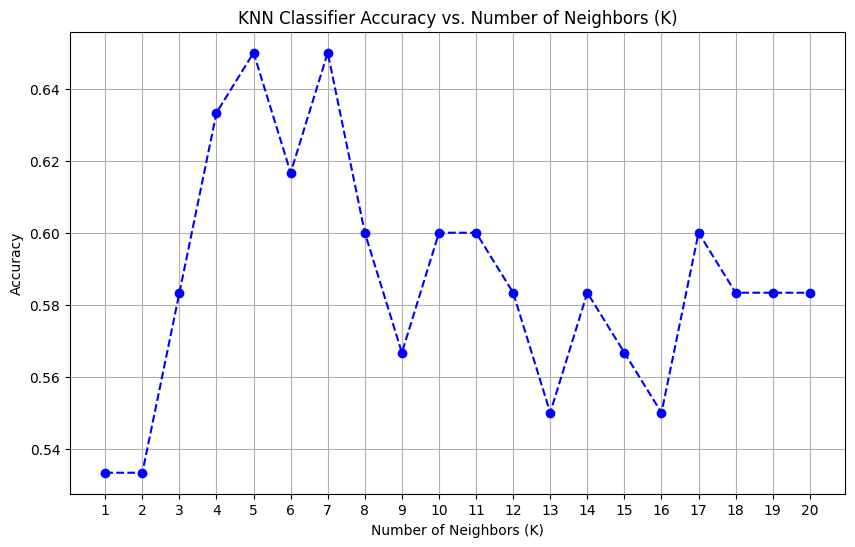

In [7]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Determine an optimal k by iterating through different values
accuracies = []
k_range = range(1, 21) # Test k from 1 to 20

# Check if training data exists before proceeding
if 'X_train_scaled' not in locals() or 'y_train' not in locals() or 'X_test_scaled' not in locals() or 'y_test' not in locals():
    print("Warning: Training/testing data (X_train_scaled, y_train, etc.) not found. Please ensure previous data preprocessing steps are executed.")
else:
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_scaled, y_train)
        y_pred = knn.predict(X_test_scaled)
        accuracies.append(accuracy_score(y_test, y_pred))

    # Only proceed to find optimal k and train if accuracies were collected
    if accuracies:
        # Find the optimal k
        optimal_k = k_range[np.argmax(accuracies)]
        max_accuracy = np.max(accuracies)

        print(f"Optimal K value: {optimal_k}")
        print(f"Maximum Accuracy for optimal K: {max_accuracy:.4f}")

        # Train the KNN model with the optimal k
        knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
        knn_optimal.fit(X_train_scaled, y_train)
        y_pred_optimal = knn_optimal.predict(X_test_scaled)

        # Evaluate the model
        accuracy = accuracy_score(y_test, y_pred_optimal)
        print(f"\nKNN Model Accuracy with optimal k={optimal_k}: {accuracy:.4f}")

        # Plotting Accuracy vs. K Value
        fig = plt.figure(figsize=(10, 6))
        plt.plot(k_range, accuracies, marker='o', linestyle='--', color='blue')
        plt.title('KNN Classifier Accuracy vs. Number of Neighbors (K)')
        plt.xlabel('Number of Neighbors (K)')
        plt.ylabel('Accuracy')
        plt.xticks(k_range) # Ensure all K values are shown on x-axis
        plt.grid(True)
        plt.show()
    else:
        print("No accuracies were recorded. KNN model training and plotting skipped due to missing data.")